# KPIs do Sistema de Suporte à Decisão — Previsão de Reincidência

**Projeto:** DSS para Previsão de Reincidência Criminal  
**Dados:** NIJ Recidivism Forecasting Challenge (Georgia, EUA, 2013–2015)

---

## Objetivo desta análise

Métricas técnicas como Acurácia, AUC-ROC e KS medem a qualidade discriminativa do modelo, mas não respondem à pergunta mais importante para a gestão pública:

> **Quanto vale, em dólares e em vidas, implantar este sistema?**

Esta análise traduz o desempenho técnico em **KPIs de negócio** — indicadores que quantificam o impacto social do DSS em função do **ponto de operação** (limiar de corte θ do score).

### Conceito central: ponto de operação (θ)

O modelo atribui a cada indivíduo um score $P(\text{Não Reincidiu})$ entre 0 e 1. O limiar θ define a decisão binária:

- **Score < θ** → classificado como **ALTO RISCO** (prediz reincidência) → supervisão intensiva  
- **Score ≥ θ** → classificado como **BAIXO RISCO** (prediz não-reincidência) → supervisão padrão

Ao variar θ de 0 a 1 controlamos o trade-off entre detectar reincidentes e evitar supervisão desnecessária. O padrão em machine learning é θ = 0,50, mas o ponto ótimo para os KPIs de negócio raramente é 50%.

### KPIs definidos

| # | KPI | O que mede |
|---|-----|------------|
| 1 | **Valor Líquido Agregado** | KPI síntese: benefício social − custo operacional — **define o θ ótimo** |
| 2 | Sensibilidade e Especificidade | Taxa de detecção de risco vs. falsos alarmes |
| 3 | Reincidências e Hospitalizações Evitadas | Impacto concreto em segurança e saúde pública |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})


In [2]:
# =============================================================================
# LEITURA E PREPARAÇÃO DOS DADOS
# Carregar dados já transformados
# =============================================================================

ARQUIVO = 'dados/dados_transformados.csv'   # ajuste o caminho se necessário
LABEL   = 'Recidivism_Within_3years'
SEED    = 42

df = pd.read_csv(ARQUIVO)

print(f"Dataset: {df.shape[0]:,} registros × {df.shape[1]} colunas")
print(f"\nDistribuição da variável resposta:")
vc = df[LABEL].value_counts().sort_index()
print(f"  0 — Reincidiu      : {vc[0]:>6,} ({vc[0]/len(df)*100:.1f}%)")
print(f"  1 — Não Reincidiu  : {vc[1]:>6,} ({vc[1]/len(df)*100:.1f}%)")


Dataset: 25,835 registros × 44 colunas

Distribuição da variável resposta:
  0 — Reincidiu      : 14,904 (57.7%)
  1 — Não Reincidiu  : 10,931 (42.3%)


In [3]:
# =============================================================================
# TREINAR MODELO (Regressão Logística — modelo principal do projeto)
# =============================================================================

FEATURES = [c for c in df.columns if c != LABEL]
X, y     = df[FEATURES], df[LABEL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Modelo com regularização L1 (C=0.003 — selecionado na análise anterior)
lr = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.003,
    random_state=SEED, max_iter=1000
)
lr.fit(X_train_sc, y_train)

# Scores de probabilidade no conjunto de teste
y_proba = lr.predict_proba(X_test_sc)[:, 1]   # P(Não Reincidiu)
y_true  = y_test.values

auc = roc_auc_score(y_test, y_proba)
print(f"Conjunto de teste : {len(y_true):,} registros")
print(f"Reincidentes      : {(y_true==0).sum():,} ({(y_true==0).mean()*100:.1f}%)")
print(f"Não Reincidentes  : {(y_true==1).sum():,} ({(y_true==1).mean()*100:.1f}%)")
print(f"AUC-ROC           : {auc:.4f}")
print(f"\nScore mín={y_proba.min():.3f} | máx={y_proba.max():.3f} | média={y_proba.mean():.3f}")


Conjunto de teste : 7,751 registros
Reincidentes      : 4,471 (57.7%)
Não Reincidentes  : 3,280 (42.3%)
AUC-ROC           : 0.7384

Score mín=0.099 | máx=0.893 | média=0.442


## 1. Parâmetros de Custo

Todos os valores são em **dólares americanos (USD, referência 2014–2015)**, alinhados com o período e localização dos dados (Georgia, EUA, 2013–2015).

### Composição do custo social por reincidência

O custo por reincidência inclui toda a cadeia de resposta do sistema criminal:

| Componente | Valor (USD 2015) | Fonte |
|---|---|---|
| Encarceramento (média 2,5 anos × US$ 22.000/ano) | US$ 55.000 | Vera Institute of Justice (2017) — estados do Sul |
| Custos judiciais e de processo | US$ 10.000 | Bureau of Justice Statistics (2016) |
| Custos de aplicação da lei | US$ 5.000 | BJS (2016) |
| Custos tangíveis à vítima (médicos, perda de salário) | US$ 8.000 | McCollister, French & Fang (2010) — tangíveis |
| **Total conservador** | **US$ 78.000** | — |

> Optamos pelo valor conservador (sem custos intangíveis de dor e sofrimento) para maior defensabilidade acadêmica. McCollister et al. (2010) estimam US$ 107.000 para agressão grave incluindo intangíveis.

### Custo de supervisão

Supervisão padrão (probation/parole): ~US$ 1.500/ano. Supervisão intensiva (monitoramento eletrônico + visitas frequentes): ~US$ 7.500/ano. Custo incremental: **US$ 6.000/ano por pessoa**.

### Referências

- **McCollister, K.E., French, M.T., & Fang, H. (2010).** The cost of crime to society. *Drug and Alcohol Dependence*, 108(1-2), 98–109.
- **Vera Institute of Justice (2017).** The Price of Prisons: Examining State Spending Trends, 2010–2015.
- **Bureau of Justice Statistics (2016).** Justice Expenditure and Employment Extracts, 2012.
- **National Institute of Justice (2022).** Community Corrections. https://bjs.ojp.gov/topics/corrections/community-corrections
- **Aos, S., Miller, M., & Drake, E. (2011).** Evidence-based adult corrections programs. Washington State Institute for Public Policy.


In [4]:
# =============================================================================
# PARÂMETROS DE CUSTO
# Valores em USD (dólares americanos, referência 2014–2015)
#
# FONTES:
# [1] McCollister, French & Fang (2010). Drug and Alcohol Dependence, 108(1-2).
# [2] Vera Institute of Justice (2017). Price of Prisons 2015.
# [3] Bureau of Prisons / DOJ (2015). Federal Register, March 9, 2015.
# [4] National Institute of Justice (2022). Community Corrections.
# [5] Aos, Miller & Drake (2011). Washington State Institute for Public Policy.
# =============================================================================

CUSTOS = {
    # Custo social médio por reincidência grave (conservador — sem intangíveis)
    # Encarceramento ($55k) + judicial ($10k) + policial ($5k) + vítima tangível ($8k)
    'custo_por_reincidencia'      : 78_000,   # USD por evento  [1][2][3]

    # Custo INCREMENTAL de supervisão intensiva vs. padrão por ano
    # Intensiva (~$7.500/ano) - Padrão (~$1.500/ano) = $6.000 incremental  [4]
    'custo_incremental_supervisao': 6_000,    # USD/pessoa/ano

    # Taxa de prevenção: % de reincidências evitadas pela supervisão intensiva
    # Meta-análise de programas de supervisão comunitária  [5]
    'taxa_prevencao'              : 0.30,     # 30%

    # Taxa de hospitalização: % de reincidências que geram internação hospitalar
    # (mantida apenas para o KPI 2 de saúde pública)
    'taxa_vitima_hospitalizacao'  : 0.15,     # 15%

    # Custo médio de internação hospitalar por vítima de crime violento
    # Diária ~US$ 2.500 × 3 dias médios  [4]
    'custo_hospitalar_por_vitima' : 7_500,    # USD por vítima
}

PERIODO_ANOS = 3   # período de análise (anos de supervisão cobertos)

# Benefício por reincidência evitada (usado no KPI 3 — Valor Líquido)
# Inclui apenas o custo do crime, sem hospitalização
BENEF_POR_REINC = CUSTOS['custo_por_reincidencia'] * CUSTOS['taxa_prevencao']

print("Parâmetros de custo — USD (referência 2014–2015):")
print(f"  Custo por reincidência grave       : US$ {CUSTOS['custo_por_reincidencia']:>8,.0f}  [McCollister et al., 2010 + BJS]")
print(f"  Custo incremental de supervisão    : US$ {CUSTOS['custo_incremental_supervisao']:>8,.0f}/ano  [NIJ, 2022]")
print(f"  Taxa de prevenção                  :     {CUSTOS['taxa_prevencao']*100:>7.0f}%  [Aos et al., 2011]")
print(f"  Taxa de hospitalização (KPI 2)     :     {CUSTOS['taxa_vitima_hospitalizacao']*100:>7.0f}%")
print(f"  Custo hospitalar por vítima (KPI 2): US$ {CUSTOS['custo_hospitalar_por_vitima']:>8,.0f}")
print(f"  Período de análise                 :     {PERIODO_ANOS:>7} anos")
print()
print(f"Benefício por reincidência evitada   : US$ {BENEF_POR_REINC:>8,.0f}")
print(f"Custo de supervisão por pessoa (3a)  : US$ {CUSTOS['custo_incremental_supervisao']*PERIODO_ANOS:>8,.0f}")
print(f"Breakeven (precisão mínima)          :     {CUSTOS['custo_incremental_supervisao']*PERIODO_ANOS/BENEF_POR_REINC*100:>7.1f}%")


Parâmetros de custo — USD (referência 2014–2015):
  Custo por reincidência grave       : US$   78,000  [McCollister et al., 2010 + BJS]
  Custo incremental de supervisão    : US$    6,000/ano  [NIJ, 2022]
  Taxa de prevenção                  :          30%  [Aos et al., 2011]
  Taxa de hospitalização (KPI 2)     :          15%
  Custo hospitalar por vítima (KPI 2): US$    7,500
  Período de análise                 :           3 anos

Benefício por reincidência evitada   : US$   23,400
Custo de supervisão por pessoa (3a)  : US$   18,000
Breakeven (precisão mínima)          :        76.9%


## 2. Cálculo dos KPIs por Limiar de Corte

Para cada valor de θ entre 0 e 1, calculamos os 3 KPIs.  
O KPI síntese é o **Valor Líquido Agregado**:

$$\text{VLA}(\theta) = \underbrace{TP(\theta) \cdot C_{crime} \cdot r_{prev}}_{\text{Benefício social}} - \underbrace{(TP + FP)(\theta) \cdot \Delta C_{sup} \cdot T}_{\text{Custo operacional}}$$

Onde:
- $TP(\theta)$ = reincidentes corretamente identificados no limiar θ
- $C_{crime}$ = custo social por reincidência (US$ 78.000)
- $r_{prev}$ = taxa de prevenção (30%)
- $\Delta C_{sup}$ = custo incremental de supervisão intensiva (US$ 6.000/ano)
- $T$ = período de análise (3 anos)


In [5]:
# =============================================================================
# CÁLCULO DOS KPIs PARA TODOS OS LIMIARES
# Para cada θ: calcula TP, FP, TN, FN e os 3 KPIs de negócio
# =============================================================================

thresholds  = np.linspace(0.01, 0.99, 500)
n_total     = len(y_true)
n_reincid   = int((y_true == 0).sum())
n_nao_reinc = int((y_true == 1).sum())

resultados = []
for t in thresholds:
    # score < θ → ALTO RISCO → supervisão intensiva
    pred_alto = (y_proba < t)

    TP = int(((pred_alto) & (y_true == 0)).sum())
    FP = int(((pred_alto) & (y_true == 1)).sum())
    TN = int(((~pred_alto) & (y_true == 1)).sum())
    FN = int(((~pred_alto) & (y_true == 0)).sum())
    n_sup = TP + FP

    # ── KPI 1: Sensibilidade e Especificidade ─────────────────────────────
    kpi1_sensib = TP / n_reincid   if n_reincid  > 0 else 0
    kpi1_espec  = TN / n_nao_reinc if n_nao_reinc > 0 else 0

    # ── KPI 2: Reincidências e Hospitalizações Evitadas ───────────────────
    kpi2_reinc_evit = TP * CUSTOS['taxa_prevencao']
    kpi2_hosp_evit  = kpi2_reinc_evit * CUSTOS['taxa_vitima_hospitalizacao']

    # ── KPI 3: Valor Líquido Agregado ─────────────────────────────────────
    beneficio       = TP * BENEF_POR_REINC
    custo_op        = n_sup * CUSTOS['custo_incremental_supervisao'] * PERIODO_ANOS
    kpi3_vliq       = beneficio - custo_op

    resultados.append({
        'threshold'        : t,
        'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
        'n_supervisionados': n_sup,
        'pct_sup'          : n_sup / n_total * 100,
        'kpi1_sensib'      : kpi1_sensib,
        'kpi1_espec'       : kpi1_espec,
        'kpi2_reinc_evit'  : kpi2_reinc_evit,
        'kpi2_hosp_evit'   : kpi2_hosp_evit,
        'kpi3_benef_MM'    : beneficio  / 1e6,
        'kpi3_custo_MM'    : custo_op   / 1e6,
        'kpi3_vliq_MM'     : kpi3_vliq  / 1e6,
    })

df_kpi = pd.DataFrame(resultados)

idx_opt = df_kpi['kpi3_vliq_MM'].idxmax()
idx_t50 = (df_kpi['threshold'] - 0.50).abs().idxmin()
T_OTIMO = df_kpi.loc[idx_opt, 'threshold']

print(f"Threshold padrão (0.5) : θ = 0.500")
print(f"Threshold ótimo (VLA)  : θ = {T_OTIMO:.3f}")


Threshold padrão (0.5) : θ = 0.500
Threshold ótimo (VLA)  : θ = 0.297


## 3. KPIs por Ponto de Operação

Os KPIs são apresentados na seguinte ordem:

1. **Valor Líquido Agregado** — define o θ ótimo que será referenciado nos demais gráficos
2. **Sensibilidade e Especificidade** — o trade-off de detecção no ponto ótimo
3. **Reincidências e Hospitalizações Evitadas** — o impacto social concreto

As linhas verticais tracejadas marcam:
- **θ = 0,50** (cinza): threshold padrão de machine learning
- **θ ótimo** (verde): threshold que maximiza o Valor Líquido Agregado


### KPI 1 — Valor Líquido Agregado

$$\text{VLA}(\theta) = TP(\theta) \cdot r_{prev} \cdot C_{crime} - N_{sup}(\theta) \cdot \Delta C_{sup} \cdot T$$

KPI síntese econômico: benefício social bruto menos o custo de operação do sistema de supervisão intensiva.

A curva começa em zero (ninguém supervisionado), **sobe** enquanto o benefício marginal de cada novo supervisionado supera seu custo, atinge o **pico no threshold ótimo** e **cai** quando os falsos positivos dominam — cada FP adicional custa US\$ 18.000 sem gerar benefício.

Este KPI é apresentado primeiro pois **define o ponto ótimo de operação (θ ótimo)** que será referenciado nos demais gráficos.

- **Zona verde:** sistema economicamente sustentável
- **Zona vermelha:** custo de supervisão supera o benefício gerado


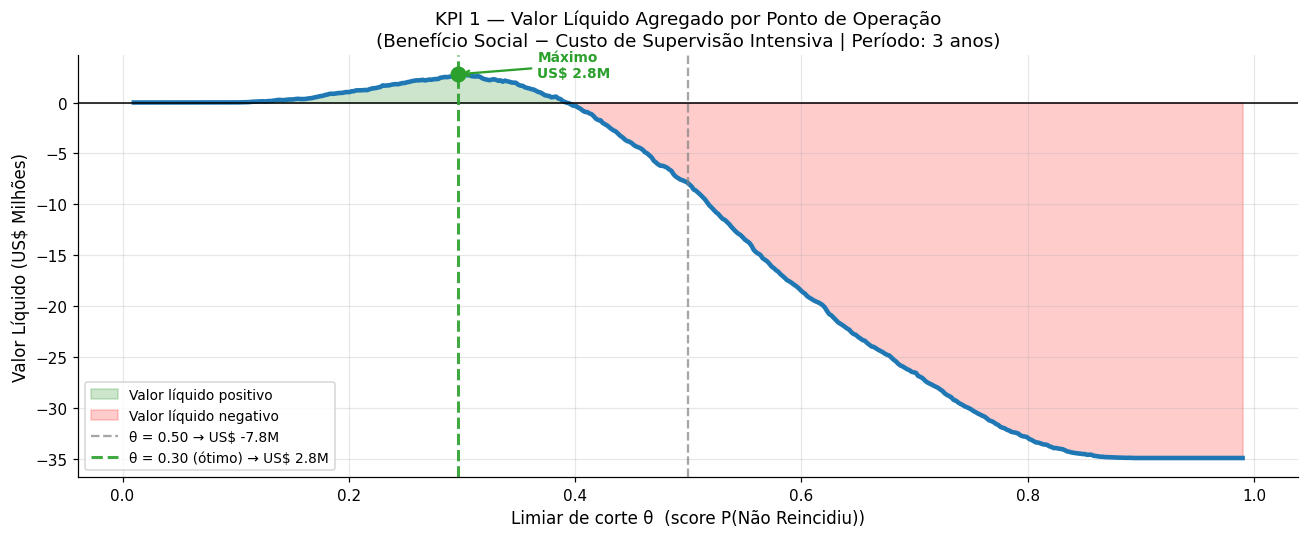

Resumo — KPI 1 (Valor Liquido Agregado)
  Threshold padrao  (0.50): US$      -8M
  Threshold otimo (0.30): US$       3M
  Custo por reincidencia  : US$ 78,000
  Custo incremental sup.  : US$ 6,000/ano
  Periodo de analise      : 3 anos


In [6]:
# =============================================================================
# KPI 1 — Valor Liquido Agregado por Ponto de Operacao
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_kpi['threshold'], df_kpi['kpi3_vliq_MM'],
        color='#1f77b4', linewidth=3)

ax.fill_between(df_kpi['threshold'], df_kpi['kpi3_vliq_MM'], 0,
                where=(df_kpi['kpi3_vliq_MM'] >= 0),
                alpha=0.20, color='green', label='Valor l\u00edquido positivo')
ax.fill_between(df_kpi['threshold'], df_kpi['kpi3_vliq_MM'], 0,
                where=(df_kpi['kpi3_vliq_MM'] < 0),
                alpha=0.20, color='red', label='Valor l\u00edquido negativo')

ax.axhline(0, color='black', linewidth=1)

vliq_t50 = df_kpi.loc[idx_t50, 'kpi3_vliq_MM']
vliq_opt = df_kpi.loc[idx_opt, 'kpi3_vliq_MM']

diff_be = np.abs(df_kpi['kpi3_vliq_MM'])

ax.axvline(0.5,     color='gray',    linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'\u03b8 = 0.50 \u2192 US$ {vliq_t50:.1f}M')
ax.axvline(T_OTIMO, color='#2ca02c', linestyle='--', linewidth=2.0, alpha=0.9,
           label=f'\u03b8 = {T_OTIMO:.2f} (\u00f3timo) \u2192 US$ {vliq_opt:.1f}M')

ax.scatter([T_OTIMO], [vliq_opt], color='#2ca02c', zorder=6, s=90)
ax.annotate(
    f'M\u00e1ximo\nUS$ {vliq_opt:.1f}M',
    xy=(T_OTIMO, vliq_opt),
    xytext=(T_OTIMO + 0.07, vliq_opt * 0.90),
    fontsize=9, color='#2ca02c', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.5)
)

ax.set_xlabel('Limiar de corte \u03b8  (score P(N\u00e3o Reincidiu))', fontsize=11)
ax.set_ylabel('Valor L\u00edquido (US$ Milh\u00f5es)', fontsize=11)
ax.set_title(
    'KPI 1 — Valor L\u00edquido Agregado por Ponto de Opera\u00e7\u00e3o\n'
    '(Benef\u00edcio Social \u2212 Custo de Supervis\u00e3o Intensiva | Per\u00edodo: 3 anos)',
    fontsize=12
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('=' * 60)
print('Resumo — KPI 1 (Valor Liquido Agregado)')
print('=' * 60)
print(f"  Threshold padrao  (0.50): US$ {vliq_t50:>7.0f}M")
print(f"  Threshold otimo ({T_OTIMO:.2f}): US$ {vliq_opt:>7.0f}M")
print(f"  Custo por reincidencia  : US$ {CUSTOS['custo_por_reincidencia']:,.0f}")
print(f"  Custo incremental sup.  : US$ {CUSTOS['custo_incremental_supervisao']:,.0f}/ano")
print(f"  Periodo de analise      : {PERIODO_ANOS} anos")


### KPI 2 — Taxa de Detecção de Risco

- **Sensibilidade** = TP / (TP + FN): dos reincidentes reais, qual % o sistema identifica corretamente
- **Especificidade** = TN / (TN + FP): dos não-reincidentes reais, qual % é corretamente liberado

As curvas se movem em direções opostas — o trade-off fundamental. O **ponto de cruzamento** é onde os dois erros se igualam. A escolha do threshold depende do que o gestor prioriza: detectar mais reincidentes (alta sensibilidade) ou evitar supervisão desnecessária (alta especificidade).


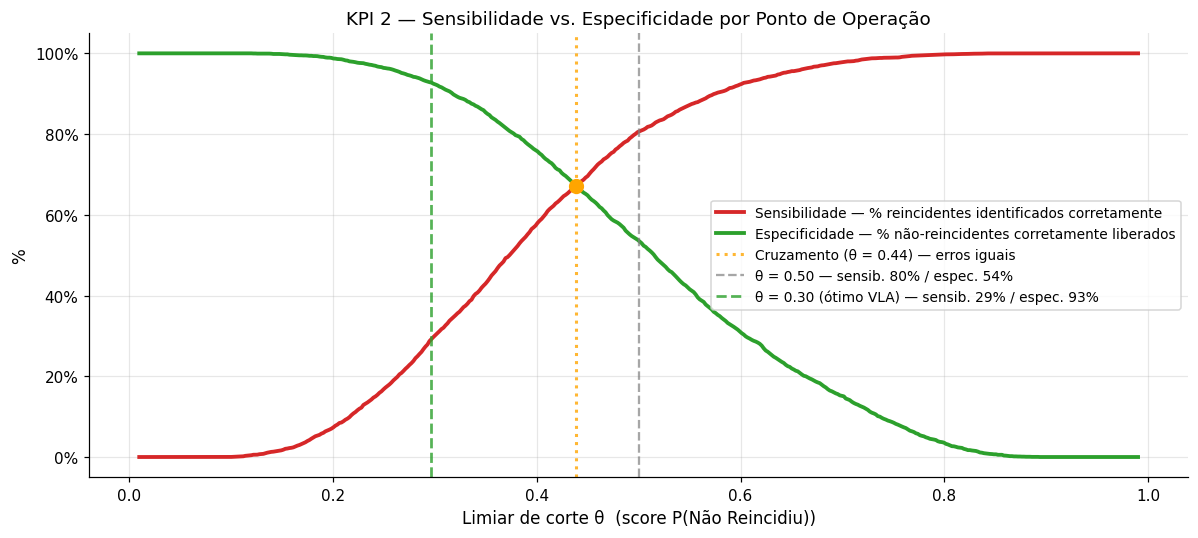

Threshold 0.50 : Sensibilidade = 80.5% | Especificidade = 53.8%
Threshold 0.30: Sensibilidade = 29.2% | Especificidade = 92.7%
Cruzamento     : theta = 0.44 (67.1% para ambas)


In [7]:
# =============================================================================
# KPI 2 — Sensibilidade e Especificidade por Ponto de Operação
# =============================================================================

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_kpi['threshold'], df_kpi['kpi1_sensib'] * 100,
        color='#d62728', linewidth=2.5,
        label='Sensibilidade — % reincidentes identificados corretamente')
ax.plot(df_kpi['threshold'], df_kpi['kpi1_espec'] * 100,
        color='#2ca02c', linewidth=2.5,
        label='Especificidade — % não-reincidentes corretamente liberados')

# Ponto de cruzamento
diff   = np.abs(df_kpi['kpi1_sensib'] - df_kpi['kpi1_espec'])
t_cruz = df_kpi.loc[diff.idxmin(), 'threshold']
y_cruz = df_kpi.loc[diff.idxmin(), 'kpi1_sensib'] * 100
ax.axvline(t_cruz, color='orange', linestyle=':', linewidth=2, alpha=0.8,
           label=f'Cruzamento (\u03b8 = {t_cruz:.2f}) — erros iguais')
ax.scatter([t_cruz], [y_cruz], color='orange', zorder=6, s=80)

# Pontos de referência
v_sensib_50   = df_kpi.loc[idx_t50,  'kpi1_sensib'] * 100
v_sensib_opt  = df_kpi.loc[idx_opt,  'kpi1_sensib'] * 100
v_espec_50    = df_kpi.loc[idx_t50,  'kpi1_espec']  * 100
v_espec_opt   = df_kpi.loc[idx_opt,  'kpi1_espec']  * 100

ax.axvline(0.5,     color='gray',    linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'\u03b8 = 0.50 — sensib. {v_sensib_50:.0f}% / espec. {v_espec_50:.0f}%')
ax.axvline(T_OTIMO, color='#2ca02c', linestyle='--', linewidth=1.8, alpha=0.8,
           label=f'\u03b8 = {T_OTIMO:.2f} (\u00f3timo VLA) — sensib. {v_sensib_opt:.0f}% / espec. {v_espec_opt:.0f}%')

ax.set_xlabel('Limiar de corte \u03b8  (score P(N\u00e3o Reincidiu))', fontsize=11)
ax.set_ylabel('%', fontsize=11)
ax.set_title('KPI 2 — Sensibilidade vs. Especificidade por Ponto de Opera\u00e7\u00e3o', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Threshold 0.50 : Sensibilidade = {v_sensib_50:.1f}% | Especificidade = {v_espec_50:.1f}%")
print(f"Threshold {T_OTIMO:.2f}: Sensibilidade = {v_sensib_opt:.1f}% | Especificidade = {v_espec_opt:.1f}%")
print(f"Cruzamento     : theta = {t_cruz:.2f} ({y_cruz:.1f}% para ambas)")


### KPI 3 — Reincidências e Hospitalizações Evitadas

$$\text{Reincidências evitadas}(\theta) = TP(\theta) \times r_{prev}$$

$$\text{Hospitalizações evitadas}(\theta) = TP(\theta) \times r_{prev} \times r_{hosp}$$

Onde $r_{prev} = 30\%$ (Aos et al., 2011) e $r_{hosp} = 15\%$.

Este KPI traduz o desempenho técnico em **impacto concreto e comunicável** — quantas pessoas deixam de sofrer as consequências de um crime por causa do sistema. Os gráficos em escala nacional mostram o impacto extrapolado para os 4,7 milhões de adultos sob supervisão comunitária nos EUA (BJS, 2014).



Fator de escala modelo → EUA: 607.6×
  θ=0.50 → 218,675 reincid./ano | 32,801 hosp./ano evitadas
  θ=0.30  → 79,413 reincid./ano | 11,912 hosp./ano evitadas
Escala nacional (BJS 2014-2015):
  População sob supervisão comunitária :    4,708,100 pessoas
  Taxa de reincidência (dataset GA)    :        57.7%
  Reincidências anuais estimadas (EUA) :      905,525
  Hospitalizações anuais estimadas     :      135,829


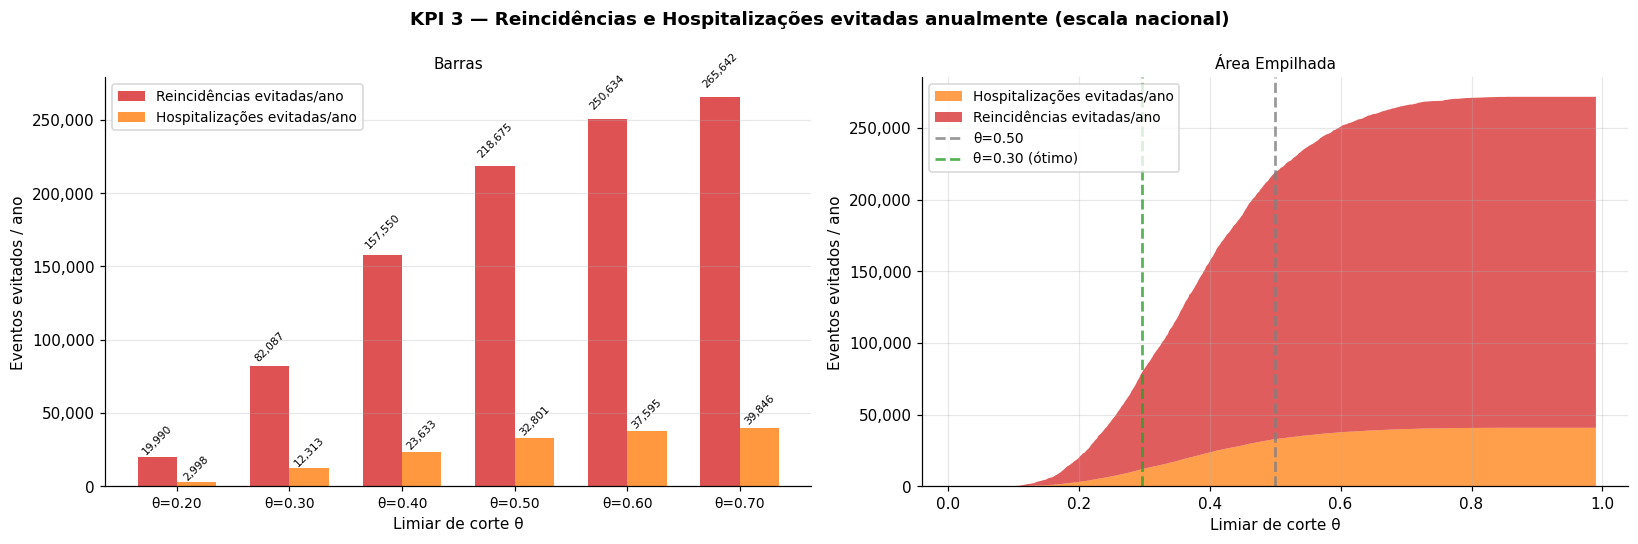


Nota: extrapolação baseada em fator de escala 607.6×
Fonte: BJS, Probation and Parole in the United States, 2014
Taxa de reinc. do dataset Georgia (2013-2015): 57.7%


In [10]:
# =============================================================================
# KPI 3 — Reincidências e Hospitalizações Evitadas (valores absolutos)
# =============================================================================

# Parâmetros populacionais (BJS, 2014-2015)
POP_SUPERVISAO_EUA  = 4_708_100   # adultos sob supervisão comunitária (BJS 2014)
TAXA_REINC_DATASET  = 0.577       # taxa de reincidência observada no dataset (Georgia)
PERIODO_ANOS        = 3           # período de acompanhamento

# Reincidências anuais esperadas na população americana (sem o sistema)
reinc_anuais_eua = POP_SUPERVISAO_EUA * TAXA_REINC_DATASET / PERIODO_ANOS
hosp_anuais_eua  = reinc_anuais_eua * CUSTOS['taxa_vitima_hospitalizacao']


# Taxas evitadas no modelo → escala nacional
df_kpi['reinc_evit_eua_ano']  = (df_kpi['kpi2_reinc_evit'] / PERIODO_ANOS) * fator_escala
df_kpi['hosp_evit_eua_ano']   = (df_kpi['kpi2_hosp_evit']  / PERIODO_ANOS) * fator_escala

r_eua_t50  = df_kpi.loc[idx_t50, 'reinc_evit_eua_ano']
r_eua_opt  = df_kpi.loc[idx_opt, 'reinc_evit_eua_ano']
h_eua_t50  = df_kpi.loc[idx_t50, 'hosp_evit_eua_ano']
h_eua_opt  = df_kpi.loc[idx_opt, 'hosp_evit_eua_ano']

n_reinc_teste_ano = (y_true == 0).sum() / PERIODO_ANOS
fator_escala = reinc_anuais_eua / n_reinc_teste_ano

print(f"\nFator de escala modelo → EUA: {fator_escala:,.1f}×")
print(f"  θ=0.50 → {r_eua_t50:,.0f} reincid./ano | {h_eua_t50:,.0f} hosp./ano evitadas")
print(f"  θ={T_OTIMO:.2f}  → {r_eua_opt:,.0f} reincid./ano | {h_eua_opt:,.0f} hosp./ano evitadas")

print(f"Escala nacional (BJS 2014-2015):")
print(f"  População sob supervisão comunitária : {POP_SUPERVISAO_EUA:>12,.0f} pessoas")
print(f"  Taxa de reincidência (dataset GA)    : {TAXA_REINC_DATASET*100:>11.1f}%")
print(f"  Reincidências anuais estimadas (EUA) : {reinc_anuais_eua:>12,.0f}")
print(f"  Hospitalizações anuais estimadas     : {hosp_anuais_eua:>12,.0f}")

# Fator de escala: proporção modelo→população nacional
# Nosso teste: 4.471 reincidentes / 3 anos = 1.490/ano
# Escala: reinc_anuais_eua / (4471/3)

# ── Gráfico comparativo: Opções B e C (escala real, sem divisão por 1000) ────
fig_comp, (ax_b, ax_c) = plt.subplots(1, 2, figsize=(15, 5))
fig_comp.suptitle(
    'KPI 3 — Reincidências e Hospitalizações evitadas anualmente (escala nacional)',
    fontsize=12, fontweight='bold'
)

# Opção B: barras agrupadas (valores reais)
thresholds_repr = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
labels_b, reinc_b, hosp_b = [], [], []
for t in thresholds_repr:
    idx_t = (df_kpi['threshold'] - t).abs().idxmin()
    labels_b.append(f'θ={t:.2f}')
    reinc_b.append(df_kpi.loc[idx_t, 'reinc_evit_eua_ano'])
    hosp_b.append(df_kpi.loc[idx_t,  'hosp_evit_eua_ano'])

x_b = np.arange(len(labels_b)); w = 0.35
bars1 = ax_b.bar(x_b - w/2, reinc_b, width=w, color='#d62728', alpha=0.8, label='Reincidências evitadas/ano')
bars2 = ax_b.bar(x_b + w/2, hosp_b,  width=w, color='#ff7f0e', alpha=0.8, label='Hospitalizações evitadas/ano')
for bar in list(bars1) + list(bars2):
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
              f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7, rotation=45)
ax_b.set_xticks(x_b); ax_b.set_xticklabels(labels_b, fontsize=9)
ax_b.set_xlabel('Limiar de corte θ', fontsize=10)
ax_b.set_ylabel('Eventos evitados / ano', fontsize=10)
ax_b.set_title(
    'Barras',
    fontsize=10
)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax_b.legend(fontsize=9); ax_b.grid(True, alpha=0.3, axis='y')

# Opção C: área empilhada (valores reais)
reinc_nao_hosp = df_kpi['reinc_evit_eua_ano'] - df_kpi['hosp_evit_eua_ano']
ax_c.stackplot(
    df_kpi['threshold'],
    df_kpi['hosp_evit_eua_ano'],
    reinc_nao_hosp,
    labels=['Hospitalizações evitadas/ano', 'Reincidências evitadas/ano'],
    colors=['#ff7f0e', '#d62728'], alpha=0.75
)
for t, cor, label in [
    (0.5,     'gray',    f'θ=0.50'),
    (T_OTIMO, '#2ca02c', f'θ={T_OTIMO:.2f} (ótimo)'),
]:
    ax_c.axvline(t, color=cor, linestyle='--', linewidth=1.8, alpha=0.8, label=label)
ax_c.set_xlabel('Limiar de corte θ', fontsize=10)
ax_c.set_ylabel('Eventos evitados / ano', fontsize=10)
ax_c.set_title(
    'Área Empilhada',
    fontsize=10
)
ax_c.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax_c.legend(fontsize=9); ax_c.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNota: extrapolação baseada em fator de escala {fator_escala:,.1f}×")
print(f"Fonte: BJS, Probation and Parole in the United States, 2014")
print(f"Taxa de reinc. do dataset Georgia (2013-2015): {TAXA_REINC_DATASET*100:.1f}%")